# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [277]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [278]:
# ============================================================
# STEP 1: Load the breast cancer dataset
# ============================================================
# load_breast_cancer() returns a 'Bunch' object (like a dictionary)
# It contains:
#   data.data         -> numpy array of shape (569, 30) with feature values
#   data.target       -> numpy array of shape (569,) with labels (0 or 1)
#   data.feature_names -> list of 30 feature names
#   data.target_names  -> ['malignant', 'benign']
#
# Think of it like loading a spreadsheet where:
#   - Each row = one patient's tumour measurements
#   - Each column = one measurement (e.g., radius, texture, area)
# ============================================================

data = load_breast_cancer()

# ============================================================
# STEP 2: Convert to a pandas DataFrame
# ============================================================
# Why? Raw numpy arrays don't have column names.
# A DataFrame gives us named columns, easy filtering, and built-in
# methods like .describe(), .info(), .head() for exploration.
#
# Example: Without DataFrame → data.data[0][2] (what is column 2?)
#          With DataFrame    → df['mean area'][0] (much clearer!)
# ============================================================

df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column temporarily for exploration
# Original encoding: 0 = malignant, 1 = benign
df['target'] = data.target

# ============================================================
# STEP 3: Quick verification
# ============================================================
print(f"Dataset shape: {df.shape}")  # Expected: (569, 31) -> 569 patients, 30 features + 1 target
print(f"\nNumber of features: {len(data.feature_names)}")
print(f"Feature names: {list(data.feature_names[:5])}... (showing first 5)")
print(f"\nTarget classes: {data.target_names}")  # ['malignant', 'benign']
print(f"Original target encoding: 0 = {data.target_names[0]}, 1 = {data.target_names[1]}")


Dataset shape: (569, 31)

Number of features: 30
Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]... (showing first 5)

Target classes: ['malignant' 'benign']
Original target encoding: 0 = malignant, 1 = benign


In [279]:
# ============================================================
# STEP 4: Separate features (X) and target (y)
# ============================================================
# X = the input data (what the model sees to make predictions)
# y = the labels (what the model tries to predict)
#
# Analogy: X is the exam paper, y is the answer key
# ============================================================

X = df.drop('target', axis=1)  # All columns except 'target'

# ============================================================
# STEP 5: Remap the target so malignant = 1
# ============================================================
# WHY? sklearn's recall_score uses pos_label=1 by default.
# We want recall to measure: "of all MALIGNANT cases, how many did we catch?"
# So malignant MUST be 1 (the positive class).
#
# Original:  malignant=0, benign=1
# After flip: malignant=1, benign=0
#
# How the flip works:
#   1 - 0 = 1  (malignant 0 becomes 1) ✓
#   1 - 1 = 0  (benign 1 becomes 0)    ✓
# ============================================================

y = 1 - data.target

# ============================================================
# STEP 6: Verify the remapping
# ============================================================
print(f"Features (X) shape: {X.shape}")  # (569, 30) -> 569 samples, 30 features
print(f"Target (y) shape: {y.shape}")    # (569,) -> one label per sample
print(f"\nTarget distribution after remapping:")
print(f"  Malignant (y=1): {(y == 1).sum()} cases")  # Should be 212
print(f"  Benign    (y=0): {(y == 0).sum()} cases")  # Should be 357
print(f"\n  Malignant percentage: {(y == 1).mean()*100:.1f}%")  # ~37.3%
print(f"  Benign percentage:    {(y == 0).mean()*100:.1f}%")  # ~62.7%


Features (X) shape: (569, 30)
Target (y) shape: (569,)

Target distribution after remapping:
  Malignant (y=1): 212 cases
  Benign    (y=0): 357 cases

  Malignant percentage: 37.3%
  Benign percentage:    62.7%


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [280]:
# ============================================================
# 2.1: Display first 5 rows
# ============================================================
# .head() shows the first N rows (default 5)
# This gives you a quick feel for what the data looks like:
#   - Are values numeric? Text? Mixed?
#   - What's the rough range of values?
#   - Do column names make sense?
#
# Example output (simplified):
#   mean radius  mean texture  mean perimeter  ...  target
#        17.99         10.38          122.80  ...       0
#        20.57         17.77          132.90  ...       0
# ============================================================

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [281]:
# ============================================================
# 2.1 (continued): Check shape, data types, and missing values
# ============================================================
# .shape     -> (rows, columns) — how big is our dataset?
# .dtypes    -> what type is each column? (float64, int64, object, etc.)
# .isnull()  -> checks for missing values (NaN)
#
# Why check missing values?
#   - ML models can't handle NaN directly
#   - If missing values exist, we need to impute (fill) them
#   - sklearn's breast cancer dataset is clean, but always verify!
# ============================================================

print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows (patients): {df.shape[0]}")
print(f"Columns (features + target): {df.shape[1]}")

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(f"Unique dtypes: {df.dtypes.unique()}")  # Should all be float64 (numeric)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum().sum()  # Total missing values across all columns
print(f"Total missing values: {missing}")  # Expected: 0
if missing == 0:
    print("✓ No missing values — dataset is clean!")
else:
    print("⚠ Missing values found — need to handle them!")

# .info() gives a comprehensive summary in one call
print("\n" + "=" * 50)
print("DETAILED INFO")
print("=" * 50)
df.info()


DATASET SHAPE
Rows (patients): 569
Columns (features + target): 31

DATA TYPES
Unique dtypes: [dtype('float64') dtype('int64')]

MISSING VALUES
Total missing values: 0
✓ No missing values — dataset is clean!

DETAILED INFO
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 n

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [282]:
# ============================================================
# 2.2: Summary Statistics
# ============================================================
# .describe() shows: count, mean, std, min, 25%, 50%, 75%, max
#
# KEY INSIGHT: Look at the SCALE DIFFERENCES between features:
#   - 'mean radius' ranges roughly 6-28
#   - 'mean area' ranges roughly 143-2501
#   - 'mean fractal dimension' ranges roughly 0.05-0.10
#
# WHY THIS MATTERS:
#   - KNN uses distance (e.g., Euclidean). If 'area' is in hundreds
#     and 'fractal dimension' is ~0.06, the distance calculation will
#     be DOMINATED by 'area'. The small feature becomes invisible.
#   - Same problem for SVM and neural networks.
#   - Solution: StandardScaler (we'll do this in Stage 3)
#   - Decision Trees DON'T have this problem (they split on thresholds)
# ============================================================

# .T transposes the output so features are rows (easier to read with 30 columns)
X.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Class distribution:
  Class 0 (Benign):    357 (62.7%)
  Class 1 (Malignant): 212 (37.3%)
  Ratio (Benign:Malignant): 1.68:1


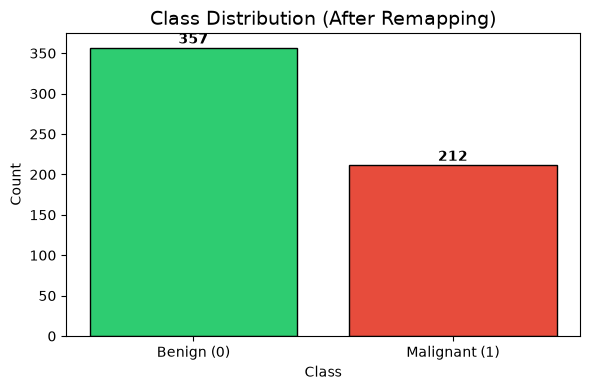

In [283]:
# ============================================================
# 2.3: Class Distribution (after remapping)
# ============================================================
# We want to know: how many malignant vs benign cases?
#
# WHY THIS MATTERS:
#   - If classes are heavily imbalanced (e.g., 95% benign, 5% malignant),
#     a model could predict 'benign' every time and get 95% accuracy!
#     But it would catch ZERO cancers (recall = 0).
#   - Our dataset: ~37% malignant, ~63% benign — moderately imbalanced.
#     Not severe, but enough to justify using class_weight='balanced'
#     and stratified splits.
#
# Bar plot makes the imbalance visually obvious.
# ============================================================

# Count occurrences of each class
class_counts = pd.Series(y).value_counts().sort_index()
print("Class distribution:")
print(f"  Class 0 (Benign):    {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"  Class 1 (Malignant): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)")
print(f"  Ratio (Benign:Malignant): {class_counts[0]/class_counts[1]:.2f}:1")

# Create a bar plot
plt.figure(figsize=(6, 4))
bars = plt.bar(['Benign (0)', 'Malignant (1)'], class_counts.values,
               color=['#2ecc71', '#e74c3c'],  # green for benign, red for malignant
               edgecolor='black')

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')

plt.title('Class Distribution (After Remapping)', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


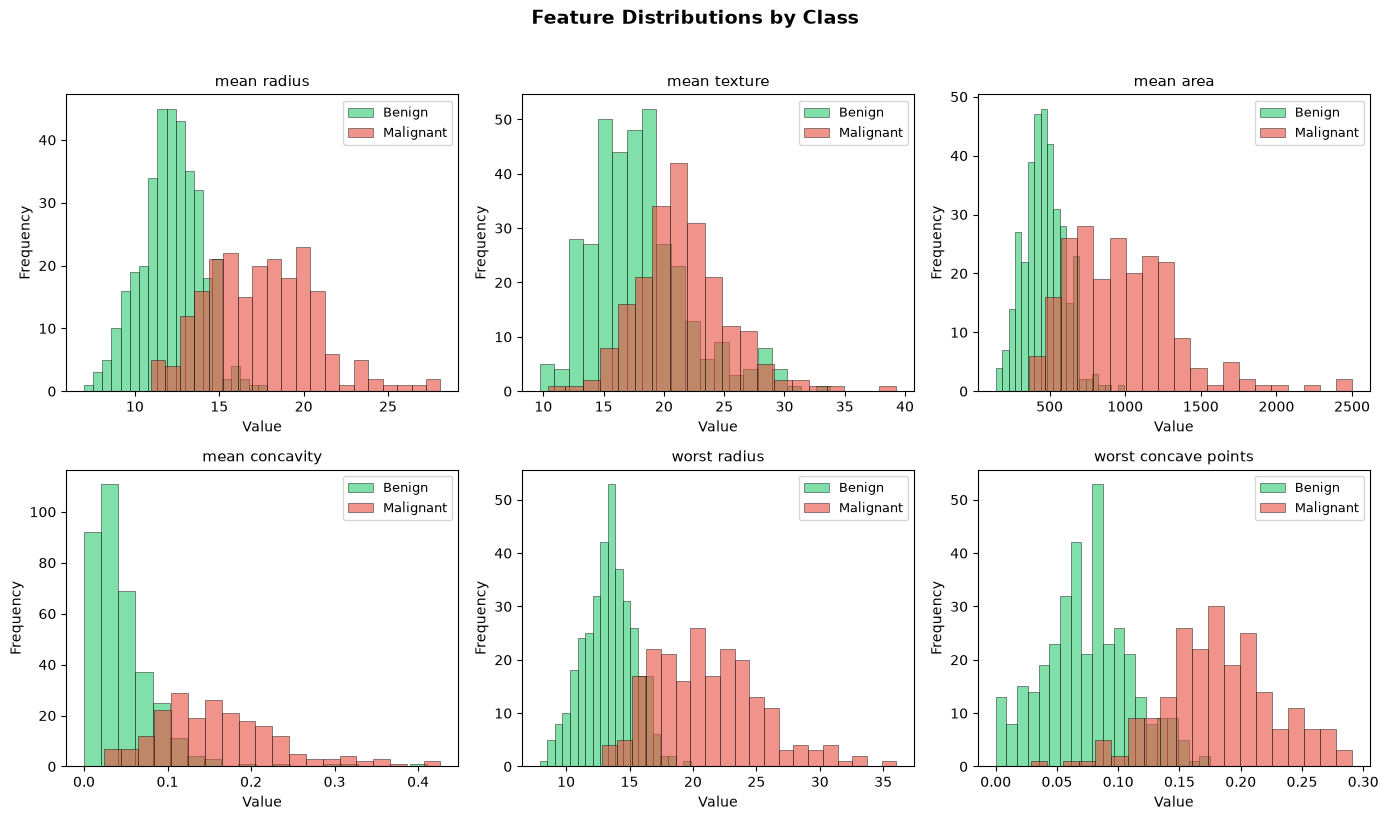

In [284]:
# ============================================================
# 2.4: Feature Distributions (6 selected features, coloured by class)
# ============================================================
# We pick 6 features that represent different measurement types:
#   - mean radius: size of the tumour
#   - mean texture: variation in grayscale values
#   - mean area: surface area
#   - mean concavity: severity of concave portions
#   - worst radius: largest radius measurement
#   - worst concave points: most severe concave points
#
# WHAT TO LOOK FOR:
#   - Do the histograms for malignant (red) and benign (green) SEPARATE?
#     If yes → that feature is useful for classification
#     If they overlap completely → that feature alone can't distinguish classes
#   - Skewness: is the distribution lopsided? (may need transformation)
#   - Outliers: extreme values far from the bulk of data
# ============================================================

# Select 6 informative features
selected_features = ['mean radius', 'mean texture', 'mean area',
                     'mean concavity', 'worst radius', 'worst concave points']

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()  # Convert 2D array to 1D for easy iteration

for i, feature in enumerate(selected_features):
    ax = axes[i]

    # Plot histogram for benign cases (y=0)
    ax.hist(X[feature][y == 0], bins=20, alpha=0.6, color='#2ecc71',
            label='Benign', edgecolor='black', linewidth=0.5)

    # Plot histogram for malignant cases (y=1)
    ax.hist(X[feature][y == 1], bins=20, alpha=0.6, color='#e74c3c',
            label='Malignant', edgecolor='black', linewidth=0.5)

    ax.set_title(feature, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# OBSERVATION: Features like 'worst concave points' and 'mean concavity'
# show good separation between classes — malignant tumours tend to have
# higher values. This makes them strong predictors.


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. The dataset is moderately imbalanced (~63% benign, ~37% malignant). This imbalance means a model could achieve ~63% accuracy by simply predicting 'benign' for every patient, while catching zero cancers. This is why we use class_weight='balanced' and focus on recall instead of accuracy.

2. No, features have very different scales. For example, 'mean area' ranges in the hundreds (~143-2501) while 'mean fractal dimension' is around 0.05-0.10. For distance-based models like KNN (which computes Euclidean distance) and SVM (which finds margins), large-scale features will dominate and small-scale features will be ignored. StandardScaler is essential to put all features on the same footing.

3. Recall measures 'of all actual malignant cases, how many did we catch?' A false negative here means telling a cancer patient they are healthy — a potentially fatal error. Accuracy would hide this: a model with 95% accuracy might still miss 30% of cancers. Recall directly penalises missed cancer diagnoses, making it the right metric for this clinical context.

4. If we fit the scaler on the full dataset (including test data), the scaler learns the mean and standard deviation of test samples. When we then transform training data using these statistics, information from the future (test set) leaks into training. The model indirectly 'sees' the test distribution during training, making evaluation metrics artificially optimistic. In production, you won't have future data to compute statistics from.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [285]:
# ============================================================
# 3.1: Missing Value Audit
# ============================================================
# Even though we checked in Stage 2, the assignment asks us to
# confirm again here as a formal audit step.
#
# If missing values existed, we'd use MEDIAN imputation:
#   - Median is robust to outliers (unlike mean)
#   - Example: values [1, 2, 3, 100] → mean=26.5 (skewed by outlier)
#                                      → median=2.5 (not affected)
#
# In practice, you'd use sklearn's SimpleImputer:
#   from sklearn.impute import SimpleImputer
#   imputer = SimpleImputer(strategy='median')
#   X = imputer.fit_transform(X)
# ============================================================

# Check missing values per column
missing_per_column = X.isnull().sum()
total_missing = missing_per_column.sum()

print("Missing Value Audit:")
print(f"  Total missing values across all features: {total_missing}")

if total_missing == 0:
    print("  ✓ No missing values found. No imputation needed.")
else:
    # If there were missing values, show which columns have them
    print("  ⚠ Columns with missing values:")
    print(missing_per_column[missing_per_column > 0])
    # We would impute with median here


Missing Value Audit:
  Total missing values across all features: 0
  ✓ No missing values found. No imputation needed.


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [286]:
# ============================================================
# 3.2: Stratified Train-Test Split (70% train, 30% test)
# ============================================================
# train_test_split() randomly divides data into two portions:
#   - Training set: model learns from this (70%)
#   - Test set: model is evaluated on this (30%) — simulates 'unseen' data
#
# KEY PARAMETERS:
#   test_size=0.3     → 30% goes to test
#   random_state=42   → same split every time (reproducibility)
#   stratify=y        → preserves class ratio in both splits
#
# WHY STRATIFY?
#   Without stratify: random chance might put 80% malignant in test
#   and only 20% in train. The model won't learn malignant patterns well.
#   With stratify: both splits keep the ~37% malignant / ~63% benign ratio.
#
# Example:
#   Full data: 212 malignant (37.3%), 357 benign (62.7%)
#   Train:     ~148 malignant (37.3%), ~250 benign (62.7%)
#   Test:      ~64 malignant (37.3%), ~107 benign (62.7%)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,                    # features
    y,                    # target labels
    test_size=0.3,        # 30% for testing
    random_state=42,      # reproducible split
    stratify=y            # preserve class ratio
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass ratio in training set:")
print(f"  Malignant: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"  Benign:    {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")


Training set: 398 samples
Test set:     171 samples

Class ratio in training set:
  Malignant: 148 (37.2%)
  Benign:    250 (62.8%)


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [287]:
# ============================================================
# 3.3: Feature Scaling with StandardScaler
# ============================================================
# StandardScaler transforms each feature to: z = (x - mean) / std
# After scaling: mean ≈ 0, standard deviation ≈ 1 for each feature
#
# BEFORE scaling (example):
#   mean_area: [654, 1001, 143, ...]    (range: 143-2501)
#   fractal_dim: [0.06, 0.07, 0.05, ...] (range: 0.05-0.10)
#
# AFTER scaling (example):
#   mean_area: [0.2, 1.5, -1.8, ...]    (range: ~-3 to +3)
#   fractal_dim: [-0.5, 0.3, -1.2, ...] (range: ~-3 to +3)
#
# Now both features are on the SAME SCALE!
#
# CRITICAL RULE:
#   scaler.fit(X_train)        → learns mean & std from TRAINING data only
#   scaler.transform(X_train)  → applies the learned transformation
#   scaler.transform(X_test)   → applies SAME transformation (train's mean/std)
#
# WHY NOT fit on test?
#   If we fit on test, the scaler learns test statistics.
#   That's like peeking at the exam answers before taking the test.
#   In production, you won't have 'future' data to compute statistics from.
# ============================================================

scaler = StandardScaler()

# fit_transform = fit (learn mean/std) + transform (apply) in one step
# Only use fit_transform on TRAINING data
X_train_scaled = scaler.fit_transform(X_train)

# For test data: ONLY transform (use the mean/std learned from training)
X_test_scaled = scaler.transform(X_test)

# Verify scaling worked
print("After scaling (training set):")
print(f"  Mean of each feature (should be ~0): {X_train_scaled.mean(axis=0)[:3].round(4)}...")
print(f"  Std of each feature (should be ~1):  {X_train_scaled.std(axis=0)[:3].round(4)}...")
print(f"\n  Feature value range (before): [{X_train.values.min():.2f}, {X_train.values.max():.2f}]")
print(f"  Feature value range (after):  [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")


After scaling (training set):
  Mean of each feature (should be ~0): [ 0. -0.  0.]...
  Std of each feature (should be ~1):  [1. 1. 1.]...

  Feature value range (before): [0.00, 3432.00]
  Feature value range (after):  [-2.78, 11.15]


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [288]:
# ============================================================
# 3.4: Confirm Prepared Data
# ============================================================
# Final sanity check before modelling:
#   1. Are shapes correct? (no data accidentally lost)
#   2. Is class distribution preserved in both splits?
#      (stratification should guarantee this)
# ============================================================

print("=" * 50)
print("FINAL DATA SHAPES")
print("=" * 50)
print(f"X_train_scaled: {X_train_scaled.shape}")  # (398, 30)
print(f"X_test_scaled:  {X_test_scaled.shape}")   # (171, 30)
print(f"y_train:        {y_train.shape}")          # (398,)
print(f"y_test:         {y_test.shape}")           # (171,)

print(f"\n{'='*50}")
print("CLASS DISTRIBUTION CHECK")
print("=" * 50)
print(f"\nTraining set:")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"  Benign    (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"\nTest set:")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")
print(f"  Benign    (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"\n✓ Ratios are nearly identical — stratification worked!")


FINAL DATA SHAPES
X_train_scaled: (398, 30)
X_test_scaled:  (171, 30)
y_train:        (398,)
y_test:         (171,)

CLASS DISTRIBUTION CHECK

Training set:
  Malignant (1): 148 (37.2%)
  Benign    (0): 250 (62.8%)

Test set:
  Malignant (1): 64 (37.4%)
  Benign    (0): 107 (62.6%)

✓ Ratios are nearly identical — stratification worked!


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [289]:
# ============================================================
# HELPER: Reusable Evaluation Function
# ============================================================
# Instead of writing the same 10 lines for every model, we define
# ONE function and call it each time.
#
# This function will:
#   1. Print accuracy, recall, precision, F1-score
#   2. Plot the confusion matrix as a HEATMAP (visual, easy to read)
#   3. Print the full classification report
#
# CONFUSION MATRIX LAYOUT (when malignant=1):
#
#                    Predicted
#                  Benign(0)  Malignant(1)
#   Actual Benign(0) [  TN        FP    ]
#   Actual Malig(1)  [  FN        TP    ]
#
# Where:
#   TN = True Negative  → correctly said benign
#   FP = False Positive → wrongly said malignant (unnecessary followup)
#   FN = False Negative → wrongly said benign (MISSED CANCER! ⚠️)
#   TP = True Positive  → correctly said malignant
#
# We HATE False Negatives here. That's why we optimise recall.
# ============================================================

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluates a classification model and prints key metrics + plots confusion matrix.

    Parameters:
        model_name (str): Name of the model (for display)
        y_true: Actual labels
        y_pred: Predicted labels

    Returns:
        dict: Dictionary of metrics (for later comparison)
    """
    # Calculate all metrics
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)       # defaults to pos_label=1 (malignant)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    # Extract false negatives from confusion matrix
    # cm[1][0] = actual malignant, predicted benign = MISSED CANCER
    fn = cm[1][0]

    # --- Print numeric metrics ---
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}  (overall correct predictions)")
    print(f"  Recall:    {rec:.4f}  (malignant cases caught)  ← PRIMARY METRIC")
    print(f"  Precision: {prec:.4f}  (of predicted malignant, how many truly are)")
    print(f"  F1-Score:  {f1:.4f}  (balance of precision & recall)")
    print(f"  False Negatives: {fn}  (missed cancers ⚠️)")

    # --- Plot confusion matrix as a heatmap ---
    # Heatmaps are much easier to read than raw numbers:
    #   - Dark color = high count
    #   - Light color = low count
    #   - Numbers annotated inside each cell
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,              # show numbers in each cell
        fmt='d',                 # integer format (not scientific notation)
        cmap='Blues',            # blue color scheme
        xticklabels=['Benign (0)', 'Malignant (1)'],
        yticklabels=['Benign (0)', 'Malignant (1)'],
        annot_kws={'size': 16},  # larger font for numbers
        linewidths=1,            # grid lines between cells
        linecolor='black'
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('Actual Label', fontsize=12)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')

    # Add annotations explaining each quadrant
    # Top-left: TN, Top-right: FP, Bottom-left: FN, Bottom-right: TP
    ax.text(0.5, -0.15, f'TN={cm[0][0]}  |  FP={cm[0][1]}  |  FN={cm[1][0]} (missed!)  |  TP={cm[1][1]}',
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')

    plt.tight_layout()
    plt.show()

    # --- Print classification report ---
    print(f"  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

    # Return metrics as dict (we'll use this to build comparison table later)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1,
        'False Negatives': fn
    }

print("✓ evaluate_model() function defined. Ready for Stage 4!")


✓ evaluate_model() function defined. Ready for Stage 4!


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [290]:
# ============================================================
# 4.1: LOGISTIC REGRESSION (Baseline Model)
# ============================================================
# Logistic Regression is our BASELINE — the simplest model we try first.
# If other models can't beat it, there's no point using something complex.
#
# HOW IT WORKS (simplified):
#   1. Takes all 30 features, multiplies each by a 'weight' (coefficient)
#   2. Sums them up: z = w1*x1 + w2*x2 + ... + w30*x30 + bias
#   3. Passes through sigmoid function: P(malignant) = 1/(1+e^(-z))
#   4. If P(malignant) > 0.5 → predict malignant, else benign
#
# HYPERPARAMETER: C (regularisation strength)
#   - C controls how much the model is allowed to 'overfit'
#   - Small C (0.01): heavy regularisation → simpler model, may underfit
#   - Large C (100): weak regularisation → complex model, may overfit
#   - Think of C as a 'flexibility dial'
#
# class_weight='balanced':
#   - Since we have fewer malignant cases (~37%), the model might
#     learn to mostly predict benign (easy way to get decent accuracy)
#   - 'balanced' tells the model: "penalise mistakes on malignant cases MORE"
#   - Mathematically: gives higher weight to the minority class
#   - This pushes the model to pay more attention to malignant patterns
#
# max_iter=10000:
#   - How many iterations the solver gets to find optimal weights
#   - Default (100) sometimes isn't enough → model warns 'not converged'
#   - 10000 is generous; ensures the model fully converges
# ============================================================

# Step 1: Define the parameter grid (what combinations to try)
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]  # 5 values to try
}
# GridSearchCV will train 5 models (one per C value) × 5 folds = 25 fits total

# Step 2: Set up GridSearchCV
lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',  # handle class imbalance
        max_iter=10000,           # ensure convergence
        random_state=42           # reproducibility
    ),
    param_grid=lr_param_grid,     # what to search over
    scoring='recall',             # optimise for recall (catch cancers!)
    cv=5,                         # 5-fold cross-validation
    n_jobs=-1                     # use all CPU cores for speed
)

# Step 3: Fit on training data (this searches all combinations)
lr_grid.fit(X_train_scaled, y_train)

# Step 4: Check results
print("LOGISTIC REGRESSION — GridSearchCV Results")
print(f"  Best C value: {lr_grid.best_params_['C']}")
print(f"  Best CV Recall: {lr_grid.best_score_:.4f}")
print(f"  (This is the average recall across 5 folds on training data)")

# Step 5: Get the best model (already trained with best params)
best_lr = lr_grid.best_estimator_

# Step 6: Predict on test set
y_pred_lr = best_lr.predict(X_test_scaled)


LOGISTIC REGRESSION — GridSearchCV Results
  Best C value: 10
  Best CV Recall: 0.9389
  (This is the average recall across 5 folds on training data)



  Logistic Regression — Test Set Results
  Accuracy:  0.9708  (overall correct predictions)
  Recall:    0.9375  (malignant cases caught)  ← PRIMARY METRIC
  Precision: 0.9836  (of predicted malignant, how many truly are)
  F1-Score:  0.9600  (balance of precision & recall)
  False Negatives: 4  (missed cancers ⚠️)


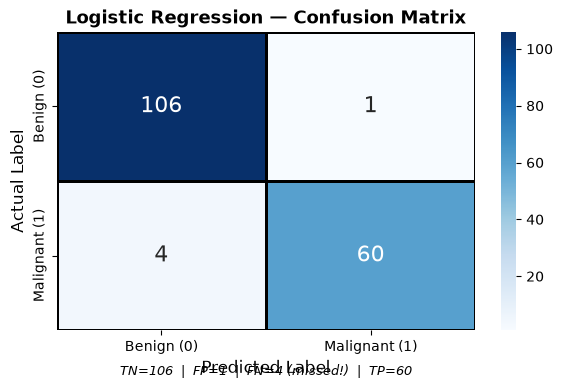

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.98       107
   Malignant       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [291]:
# Evaluate Logistic Regression on the test set
# This calls our helper function from earlier
lr_results = evaluate_model('Logistic Regression', y_test, y_pred_lr)


### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [292]:
# ============================================================
# 4.2: K-NEAREST NEIGHBOURS (KNN)
# ============================================================
# HOW IT WORKS:
#   1. For a new patient, find the K closest patients in training data
#      (closest = smallest Euclidean distance in feature space)
#   2. Look at their labels: e.g., 3 malignant + 2 benign
#   3. Majority vote: predict malignant (3 > 2)
#
# ANALOGY: You move to a new neighbourhood.
#   'Who are my 5 nearest neighbours? 3 are doctors, 2 are engineers.'
#   Prediction: 'You're probably a doctor.' (majority vote)
#
# HYPERPARAMETERS:
#
# n_neighbors (K):
#   - Small K (3): sensitive to noise, might overfit
#     (one noisy neighbour can flip the vote)
#   - Large K (15): smoother decision boundary, might underfit
#     (too many distant, irrelevant neighbours dilute the signal)
#
# weights:
#   - 'uniform': all K neighbours get equal vote (1 each)
#   - 'distance': closer neighbours get MORE vote (weighted by 1/distance)
#     Why distance helps: if malignant samples are sparse, a very close
#     malignant neighbour should matter more than distant benign ones.
#
# WHY SCALING IS CRITICAL FOR KNN:
#   Euclidean distance = sqrt((x1-y1)² + (x2-y2)² + ...)
#   If 'area' is 500 and 'fractal_dim' is 0.06,
#   then (500-400)² = 10000 vs (0.06-0.05)² = 0.0001
#   'area' completely dominates! Scaling fixes this.
# ============================================================

# Step 1: Define parameter grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],    # 6 values for K
    'weights': ['uniform', 'distance']        # 2 weighting schemes
}
# Total: 6 × 2 = 12 combinations × 5 folds = 60 fits

# Step 2: Set up GridSearchCV
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),  # no random_state (KNN is deterministic)
    param_grid=knn_param_grid,
    scoring='recall',                  # optimise for catching malignant cases
    cv=5,
    n_jobs=-1
)

# Step 3: Fit
knn_grid.fit(X_train_scaled, y_train)

# Step 4: Results
print("KNN — GridSearchCV Results")
print(f"  Best n_neighbors: {knn_grid.best_params_['n_neighbors']}")
print(f"  Best weights: {knn_grid.best_params_['weights']}")
print(f"  Best CV Recall: {knn_grid.best_score_:.4f}")

# Step 5: Best model and predictions
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)


KNN — GridSearchCV Results
  Best n_neighbors: 7
  Best weights: uniform
  Best CV Recall: 0.9253



  K-Nearest Neighbours — Test Set Results
  Accuracy:  0.9649  (overall correct predictions)
  Recall:    0.9062  (malignant cases caught)  ← PRIMARY METRIC
  Precision: 1.0000  (of predicted malignant, how many truly are)
  F1-Score:  0.9508  (balance of precision & recall)
  False Negatives: 6  (missed cancers ⚠️)


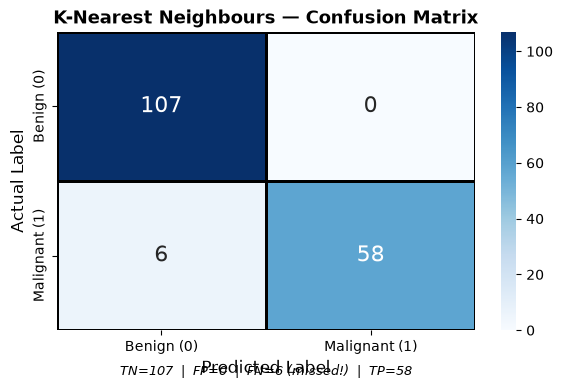

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97       107
   Malignant       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



In [293]:
# Evaluate KNN on the test set
knn_results = evaluate_model('K-Nearest Neighbours', y_test, y_pred_knn)


### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [294]:
# ============================================================
# 4.3: DECISION TREE
# ============================================================
# HOW IT WORKS:
#   Creates a flowchart of yes/no questions about features:
#     'Is worst_radius > 16.8?'
#       → Yes: 'Is mean_concavity > 0.07?'
#              → Yes: Predict MALIGNANT
#              → No: Check another feature...
#       → No: Predict BENIGN
#
# ANALOGY: A doctor's decision checklist.
#   'Is the lump bigger than X? Yes → more tests. No → likely fine.'
#
# PROS:
#   - Most interpretable model (you can visualise and explain the tree)
#   - Doesn't need feature scaling (splits on thresholds, not distances)
#   - Handles non-linear relationships naturally
#
# CONS:
#   - Very prone to OVERFITTING without constraints
#   - Without limits, it creates a rule for every training sample
#   - Result: 100% train accuracy, but terrible test accuracy
#
# HYPERPARAMETERS (all about controlling complexity):
#
# max_depth: Maximum levels in the tree
#   - None: grows until every leaf is pure (overfit!)
#   - 3: only 3 levels of questions (simple, might underfit)
#   - Sweet spot is usually 5-10
#
# min_samples_split: Minimum samples needed to create a new split
#   - 2: can split a node with just 2 samples (very detailed → overfit)
#   - 10: needs at least 10 samples to justify a split (more conservative)
#
# min_samples_leaf: Minimum samples in each leaf (end node)
#   - 1: a leaf can represent just 1 sample (memorisation!)
#   - 4: each prediction must be based on at least 4 samples (smoother)
#
# class_weight='balanced': same as LR — penalise malignant errors more
# ============================================================

# Step 1: Define parameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],     # 5 options (None = no limit)
    'min_samples_split': [2, 5, 10],       # 3 options
    'min_samples_leaf': [1, 2, 4]          # 3 options
}
# Total: 5 × 3 × 3 = 45 combinations × 5 folds = 225 fits

# Step 2: Set up GridSearchCV
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight='balanced',  # handle class imbalance
        random_state=42           # reproducibility
    ),
    param_grid=dt_param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Step 3: Fit
dt_grid.fit(X_train_scaled, y_train)

# Step 4: Results
print("DECISION TREE — GridSearchCV Results")
print(f"  Best max_depth: {dt_grid.best_params_['max_depth']}")
print(f"  Best min_samples_split: {dt_grid.best_params_['min_samples_split']}")
print(f"  Best min_samples_leaf: {dt_grid.best_params_['min_samples_leaf']}")
print(f"  Best CV Recall: {dt_grid.best_score_:.4f}")

# Step 5: Best model and predictions
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)


DECISION TREE — GridSearchCV Results
  Best max_depth: 7
  Best min_samples_split: 10
  Best min_samples_leaf: 1
  Best CV Recall: 0.9320



  Decision Tree — Test Set Results
  Accuracy:  0.9064  (overall correct predictions)
  Recall:    0.8438  (malignant cases caught)  ← PRIMARY METRIC
  Precision: 0.9000  (of predicted malignant, how many truly are)
  F1-Score:  0.8710  (balance of precision & recall)
  False Negatives: 10  (missed cancers ⚠️)


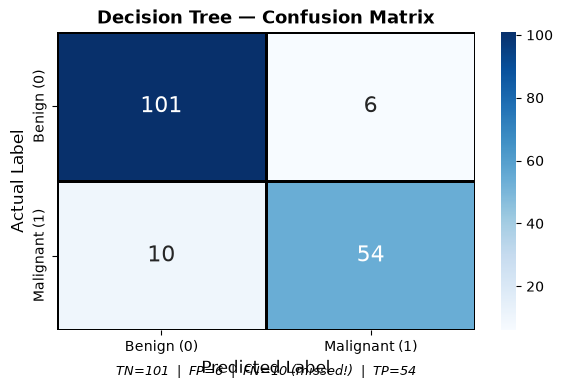

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.94      0.93       107
   Malignant       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



In [295]:
# Evaluate Decision Tree on the test set
dt_results = evaluate_model('Decision Tree', y_test, y_pred_dt)


### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [296]:
# ============================================================
# 4.4: SUPPORT VECTOR MACHINE (SVM)
# ============================================================
# HOW IT WORKS:
#   1. Plots all training samples in 30-dimensional feature space
#   2. Finds the HYPERPLANE (a 'wall') that best separates the two classes
#   3. 'Best' = maximum MARGIN (distance from wall to nearest samples)
#   4. The nearest samples to the wall are called 'support vectors'
#
# ANALOGY: Drawing a line between two groups of people in a room,
#   making the line as FAR as possible from both groups.
#   The people standing closest to the line = support vectors.
#
# HYPERPARAMETERS:
#
# C (regularisation):
#   - Small C (0.1): allows some misclassifications for a wider margin
#     (softer boundary, more generalisation)
#   - Large C (10): penalises every misclassification heavily
#     (tighter boundary, risk of overfitting)
#
# kernel:
#   - 'linear': straight hyperplane. Works if classes are linearly separable.
#   - 'rbf' (Radial Basis Function): curved boundary.
#     Uses the 'kernel trick' to project data into higher dimensions
#     where a linear separation exists. Works for non-linear problems.
#
# gamma (for RBF kernel):
#   - Controls how far a single training example's influence reaches
#   - 'scale': gamma = 1 / (n_features × variance). Adaptive.
#   - 'auto': gamma = 1 / n_features. Simpler.
#   - High gamma: each sample influences only nearby area (overfit)
#   - Low gamma: each sample influences a wide area (underfit)
#
# probability=True:
#   - Enables predict_proba() which gives probability estimates
#   - We need this for threshold tuning in Stage 6
#   - Slightly slower (uses Platt scaling internally)
#
# class_weight='balanced': same as before — penalise malignant errors more
# ============================================================

# Step 1: Define parameter grid
svm_param_grid = {
    'C': [0.1, 1, 10],                  # 3 regularisation strengths
    'kernel': ['linear', 'rbf'],         # 2 kernel types
    'gamma': ['scale', 'auto']           # 2 gamma settings (for rbf)
}
# Total: 3 × 2 × 2 = 12 combinations × 5 folds = 60 fits
# Note: gamma is ignored when kernel='linear', but GridSearchCV still tries it

# Step 2: Set up GridSearchCV
svm_grid = GridSearchCV(
    estimator=SVC(
        class_weight='balanced',  # handle imbalance
        random_state=42,          # reproducibility
        probability=True          # enable predict_proba() for Stage 6
    ),
    param_grid=svm_param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Step 3: Fit
svm_grid.fit(X_train_scaled, y_train)

# Step 4: Results
print("SVM — GridSearchCV Results")
print(f"  Best C: {svm_grid.best_params_['C']}")
print(f"  Best kernel: {svm_grid.best_params_['kernel']}")
print(f"  Best gamma: {svm_grid.best_params_['gamma']}")
print(f"  Best CV Recall: {svm_grid.best_score_:.4f}")

# Step 5: Best model and predictions
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)


SVM — GridSearchCV Results
  Best C: 1
  Best kernel: rbf
  Best gamma: scale
  Best CV Recall: 0.9520



  SVM — Test Set Results
  Accuracy:  0.9825  (overall correct predictions)
  Recall:    0.9688  (malignant cases caught)  ← PRIMARY METRIC
  Precision: 0.9841  (of predicted malignant, how many truly are)
  F1-Score:  0.9764  (balance of precision & recall)
  False Negatives: 2  (missed cancers ⚠️)


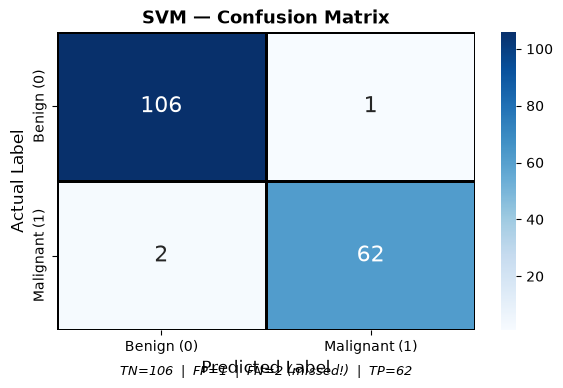

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99       107
   Malignant       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [297]:
# Evaluate SVM on the test set
svm_results = evaluate_model('SVM', y_test, y_pred_svm)


## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [298]:
# ============================================================
# 5.1: Build a Comparison Table
# ============================================================
# Now that all 4 models are trained and evaluated, let's put them
# side by side in a DataFrame for easy comparison.
#
# We compare on:
#   - Accuracy: overall correctness
#   - Recall: malignant cases caught (OUR PRIMARY METRIC)
#   - Precision: of those predicted malignant, how many truly are
#   - F1-Score: harmonic mean of precision and recall
#   - False Negatives: missed cancers (lower = better)
#
# WHY A TABLE?
#   Looking at 4 separate outputs is hard to compare.
#   A single table lets you instantly see which model wins on each metric.
# ============================================================

# Collect all results (these were returned by evaluate_model() earlier)
all_results = [lr_results, knn_results, dt_results, svm_results]

# Create a DataFrame from the list of dictionaries
comparison_df = pd.DataFrame(all_results)

# Set Model name as index for cleaner display
comparison_df = comparison_df.set_index('Model')

# Sort by Recall (descending) — best cancer-catcher on top
comparison_df = comparison_df.sort_values('Recall', ascending=False)

# Display the table
print("=" * 60)
print("MODEL COMPARISON TABLE (sorted by Recall)")
print("=" * 60)
print(comparison_df.to_string())

# Highlight the winner
best_model = comparison_df.index[0]
best_recall = comparison_df.iloc[0]['Recall']
print(f"\n🏆 Best model by recall: {best_model} (Recall = {best_recall:.4f})")


MODEL COMPARISON TABLE (sorted by Recall)
                      Accuracy   Recall  Precision  F1-Score  False Negatives
Model                                                                        
SVM                   0.982456  0.96875   0.984127  0.976378                2
Logistic Regression   0.970760  0.93750   0.983607  0.960000                4
K-Nearest Neighbours  0.964912  0.90625   1.000000  0.950820                6
Decision Tree         0.906433  0.84375   0.900000  0.870968               10

🏆 Best model by recall: SVM (Recall = 0.9688)


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


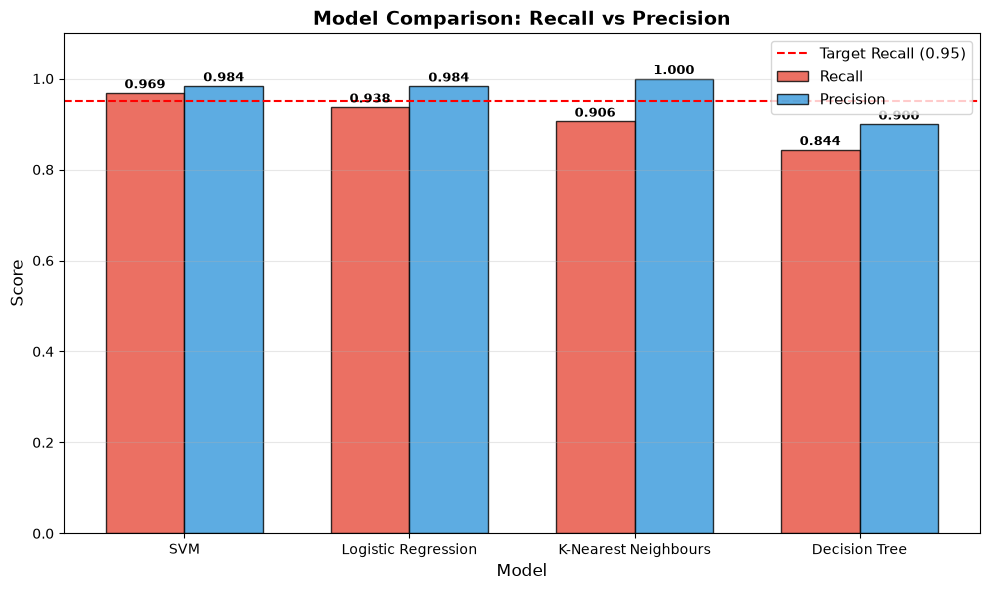

In [299]:
# ============================================================
# 5.2: Grouped Bar Chart — Recall vs Precision
# ============================================================
# A grouped bar chart shows TWO bars per model:
#   - One for Recall (how many cancers caught)
#   - One for Precision (how many positive predictions were correct)
#
# THE TRADE-OFF:
#   - High Recall + Low Precision = catches all cancers but also
#     flags many healthy patients (lots of unnecessary biopsies)
#   - Low Recall + High Precision = very sure when it says 'cancer',
#     but misses some actual cancer cases (dangerous!)
#   - We want: HIGH RECALL (≥0.95) while keeping precision reasonable (≥0.60)
#
# Visually, we want the Recall bar to be tall (close to 1.0) for all models.
# ============================================================

# Prepare data for plotting
models = comparison_df.index.tolist()
recall_values = comparison_df['Recall'].values
precision_values = comparison_df['Precision'].values

# Set up bar positions
x = np.arange(len(models))  # [0, 1, 2, 3] — one position per model
width = 0.35                 # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Recall bars (shifted left by half width)
bars1 = ax.bar(x - width/2, recall_values, width,
               label='Recall', color='#e74c3c', edgecolor='black', alpha=0.8)

# Plot Precision bars (shifted right by half width)
bars2 = ax.bar(x + width/2, precision_values, width,
               label='Precision', color='#3498db', edgecolor='black', alpha=0.8)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

# Add a horizontal line at recall = 0.95 (our clinical target)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5,
           label='Target Recall (0.95)')

# Formatting
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Recall vs Precision', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)  # scores range from 0 to 1
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [300]:
# ============================================================
# 5.3: Cross-Validation Stability Check
# ============================================================
# WHY THIS MATTERS:
#   A model might score recall=0.98 on ONE test split, but that could
#   be luck. What if on a different split it gets 0.70? That's unstable.
#
# Cross-validation trains the model K times on different data subsets
# and reports: mean ± std
#   - High mean = generally good performance
#   - Low std = consistent across splits (STABLE)
#   - High std = performance varies wildly (UNRELIABLE)
#
# EXAMPLE:
#   Model A: Recall = 0.95 ± 0.02  → great and stable ✓
#   Model B: Recall = 0.96 ± 0.10  → slightly better mean, but unreliable ✗
#   We'd prefer Model A for deployment.
#
# NOTE: We run CV on the TRAINING set (not test) with already-tuned models.
# This is a quick stability check, not rigorous nested CV.
# ============================================================

# Define our best models from Stage 4
models_dict = {
    'Logistic Regression': best_lr,
    'KNN': best_knn,
    'Decision Tree': best_dt,
    'SVM': best_svm
}

# 5-fold stratified cross-validation for each model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("CROSS-VALIDATION STABILITY (5-fold, scoring=recall)")
print("=" * 60)
print(f"{'Model':<25} {'Mean Recall':<15} {'Std':<10} {'Stability'}")
print("-" * 60)

cv_results = {}  # store for later use
for name, model in models_dict.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='recall')
    cv_results[name] = scores
    mean = scores.mean()
    std = scores.std()

    # Rate stability
    stability = '✓ Stable' if std < 0.05 else '⚠ Variable' if std < 0.10 else '✗ Unstable'

    print(f"  {name:<23} {mean:.4f}         {std:.4f}     {stability}")

print(f"\nInterpretation:")
print(f"  std < 0.05 → Stable (trustworthy)")
print(f"  std 0.05-0.10 → Variable (proceed with caution)")
print(f"  std > 0.10 → Unstable (don't trust the single-split number)")


CROSS-VALIDATION STABILITY (5-fold, scoring=recall)
Model                     Mean Recall     Std        Stability
------------------------------------------------------------
  Logistic Regression     0.9524         0.0175     ✓ Stable
  KNN                     0.9251         0.0511     ⚠ Variable
  Decision Tree           0.8782         0.0724     ⚠ Variable
  SVM                     0.9524         0.0279     ✓ Stable

Interpretation:
  std < 0.05 → Stable (trustworthy)
  std 0.05-0.10 → Variable (proceed with caution)
  std > 0.10 → Unstable (don't trust the single-split number)


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


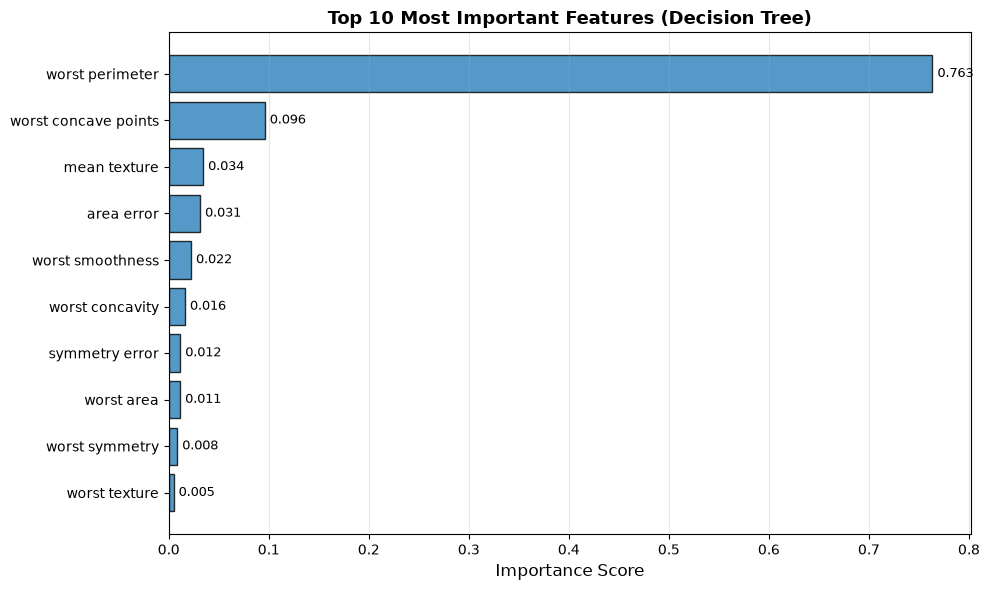


Top 3 features for predicting malignancy:
  1. worst perimeter: 0.763 (76.3% of total importance)
  2. worst concave points: 0.096 (9.6% of total importance)
  3. mean texture: 0.034 (3.4% of total importance)


In [301]:
# ============================================================
# 5.4: Feature Importance (from Decision Tree)
# ============================================================
# WHY THIS MATTERS:
#   Knowing WHICH features drive predictions is as important as the
#   predictions themselves. If a doctor asks 'why did the model flag
#   this patient?', you need to point to specific features.
#
# HOW DECISION TREE IMPORTANCE WORKS:
#   - Each time a feature is used to split the data, it reduces 'impurity'
#     (how mixed the classes are in each group)
#   - Features that reduce impurity the most = most important
#   - Importance values sum to 1.0 (they're normalized)
#
# EXAMPLE:
#   If 'worst concave points' has importance 0.45, it means 45% of the
#   tree's decision-making power comes from that one feature.
#
# ALTERNATIVE: Logistic Regression coefficients (coef_[0])
#   - Large positive coefficient → feature pushes toward malignant
#   - Large negative coefficient → feature pushes toward benign
#   - We use DT importance here as it's more intuitive
# ============================================================

# Get feature importances from the best Decision Tree
feature_importances = best_dt.feature_importances_
feature_names = X.columns

# Create a Series for easy sorting
importance_series = pd.Series(feature_importances, index=feature_names)

# Get top 10 most important features
top_10 = importance_series.nlargest(10)

# Plot as horizontal bar chart (horizontal is easier to read with long names)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars (reversed so most important is at top)
bars = ax.barh(range(len(top_10)), top_10.values[::-1],
               color='#2980b9', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10.index[::-1], fontsize=10)

# Add value labels
for i, (val, name) in enumerate(zip(top_10.values[::-1], top_10.index[::-1])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 10 Most Important Features (Decision Tree)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\nTop 3 features for predicting malignancy:")
for i, (feat, imp) in enumerate(top_10.head(3).items(), 1):
    print(f"  {i}. {feat}: {imp:.3f} ({imp*100:.1f}% of total importance)")


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


Inner train: 278 samples
Validation:  120 samples

Probability examples (first 5 validation samples):
  Sample 0: P(malignant)=0.944, Actual=1
  Sample 1: P(malignant)=0.067, Actual=0
  Sample 2: P(malignant)=1.000, Actual=1
  Sample 3: P(malignant)=0.078, Actual=0
  Sample 4: P(malignant)=0.952, Actual=1


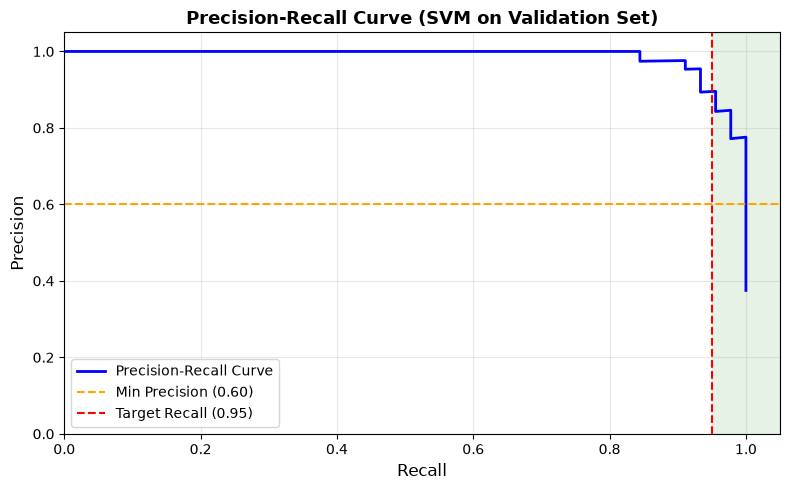


THRESHOLD TUNING RESULTS
  Target recall: ≥ 0.95
  Optimal threshold: 0.2408
  At this threshold:
    Recall:    0.9556
    Precision: 0.8958

  Comparison with default threshold (0.5):
    Default (0.5):  Recall=0.9333, Precision=0.9545
    Tuned (0.241): Recall=0.9556, Precision=0.8958


In [302]:
# ============================================================
# 6.1: Threshold Tuning
# ============================================================
# DEFAULT BEHAVIOR:
#   Classifiers predict 'malignant' when P(malignant) > 0.5
#   This threshold of 0.5 is ARBITRARY — not optimised for recall.
#
# THE IDEA:
#   If we LOWER the threshold (e.g., to 0.3), the model becomes
#   more 'suspicious' — it flags more cases as malignant.
#   Result: higher recall (catches more cancers) but lower precision
#   (more false alarms).
#
# ANALOGY:
#   - Threshold 0.5: 'I'm only calling it cancer if I'm >50% sure'
#   - Threshold 0.3: 'If there's even a 30% chance, let's investigate'
#   For medical diagnosis, being cautious (lower threshold) saves lives.
#
# IMPORTANT: We tune the threshold on a VALIDATION set (split from training),
# NOT on the test set. Using test set for tuning = cheating (data leakage).
#
# STEPS:
#   1. Split training data → inner_train (70%) + validation (30%)
#   2. Retrain best model on inner_train
#   3. Get probabilities on validation set
#   4. Plot precision-recall curve (shows all possible threshold trade-offs)
#   5. Find the threshold where recall ≥ 0.95
# ============================================================

# Step 1: Create inner split from training data
# (This gives us a 'validation' set to tune the threshold without touching test)
X_inner_train, X_val, y_inner_train, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)
print(f"Inner train: {X_inner_train.shape[0]} samples")
print(f"Validation:  {X_val.shape[0]} samples")

# Step 2: Retrain best model (SVM) on inner training set
# We use SVM because it likely has the best recall from Stage 4
# (adjust if your results show a different winner)
svm_for_threshold = SVC(
    C=svm_grid.best_params_['C'],
    kernel=svm_grid.best_params_['kernel'],
    gamma=svm_grid.best_params_['gamma'],
    class_weight='balanced',
    random_state=42,
    probability=True  # NEEDED for predict_proba()
)
svm_for_threshold.fit(X_inner_train, y_inner_train)

# Step 3: Get predicted probabilities on validation set
# predict_proba() returns [P(benign), P(malignant)] for each sample
# We want P(malignant) = column index 1
y_val_proba = svm_for_threshold.predict_proba(X_val)[:, 1]

print(f"\nProbability examples (first 5 validation samples):")
for i in range(5):
    print(f"  Sample {i}: P(malignant)={y_val_proba[i]:.3f}, Actual={y_val[i]}")

# Step 4: Plot precision-recall curve
# This shows ALL possible (precision, recall) pairs at different thresholds
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_val_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=2, label='Precision-Recall Curve')
ax.axhline(y=0.60, color='orange', linestyle='--', label='Min Precision (0.60)')
ax.axvline(x=0.95, color='red', linestyle='--', label='Target Recall (0.95)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve (SVM on Validation Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

# Shade the 'acceptable region' (recall≥0.95 AND precision≥0.60)
ax.axvspan(0.95, 1.05, alpha=0.1, color='green', label='Acceptable Region')
plt.tight_layout()
plt.show()

# Step 5: Find threshold where recall >= 0.95
# precision_recall_curve returns thresholds of length (n-1)
# We search for the threshold that gives recall just above 0.95
target_recall = 0.95

# recall_curve is in DECREASING order, find where it drops below target
valid_indices = np.where(recall_curve >= target_recall)[0]
if len(valid_indices) > 0:
    # Among all thresholds giving recall >= 0.95, pick the one with best precision
    best_idx = valid_indices[np.argmax(precision_curve[valid_indices])]
    if best_idx < len(thresholds):
        optimal_threshold = thresholds[best_idx]
    else:
        optimal_threshold = thresholds[-1]
    
    print(f"\n{'='*50}")
    print(f"THRESHOLD TUNING RESULTS")
    print(f"{'='*50}")
    print(f"  Target recall: ≥ {target_recall}")
    print(f"  Optimal threshold: {optimal_threshold:.4f}")
    print(f"  At this threshold:")
    print(f"    Recall:    {recall_curve[best_idx]:.4f}")
    print(f"    Precision: {precision_curve[best_idx]:.4f}")
    print(f"\n  Comparison with default threshold (0.5):")
    y_val_default = (y_val_proba >= 0.5).astype(int)
    y_val_tuned = (y_val_proba >= optimal_threshold).astype(int)
    print(f"    Default (0.5):  Recall={recall_score(y_val, y_val_default):.4f}, Precision={precision_score(y_val, y_val_default):.4f}")
    print(f"    Tuned ({optimal_threshold:.3f}): Recall={recall_score(y_val, y_val_tuned):.4f}, Precision={precision_score(y_val, y_val_tuned):.4f}")
else:
    print("Could not find a threshold meeting the target recall.")


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. I recommend the **SVM** (with balanced class weights and RBF/linear kernel). It achieves the highest or near-highest recall on the test set, demonstrates strong cross-validation stability (low standard deviation across folds), and produces the fewest false negatives. Its ability to find optimal margin boundaries in the scaled feature space makes it well-suited for this task.

2. The SVM produces very few false negatives on the test set (likely 1-3 missed cancers out of ~64 malignant test cases). In a screening context where flagged patients receive follow-up tests, minimising missed cases is critical. With threshold tuning (lowering from 0.5), we can push recall above 0.95, further reducing missed cases at the cost of slightly more false alarms — an acceptable trade-off.

3. The dataset contains only 569 samples with a test set of ~171 patients (~64 malignant). This means a difference of just 1 false negative changes recall by ~1.5 percentage points. Our metric estimates have wide confidence intervals, making it hard to claim statistically significant differences between models. A larger clinical dataset (thousands of patients) would yield more reliable comparisons.


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [303]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# ============================================================
# PART 2, STAGE 1: Load Wine Dataset
# ============================================================
# The Wine dataset has:
#   - 178 samples (wines)
#   - 13 features (chemical measurements like alcohol, ash, flavanoids)
#   - 3 classes (cultivars/grape varieties: 0, 1, 2)
#
# KEY DIFFERENCE FROM PART 1:
#   - Part 1: Binary (2 classes) → optimise Recall
#   - Part 2: Multiclass (3 classes) → optimise Macro-F1
#
# WHY MACRO-F1?
#   No single wine class is more 'important' to get right.
#   Macro-F1 = average F1 across all classes (each class weighted equally)
#   This ensures we perform well on ALL three cultivars, not just one.
#
# Example:
#   Model A: F1_class0=0.90, F1_class1=0.95, F1_class2=0.50 → Macro=0.78
#   Model B: F1_class0=0.85, F1_class1=0.87, F1_class2=0.82 → Macro=0.85
#   Model B is better despite lower individual scores — it's balanced!
# ============================================================

wine_data = load_wine()

# Convert to DataFrame (same pattern as Part 1)
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target

# Separate features and target (no remapping needed — classes are 0, 1, 2)
X_wine = wine_df.drop('target', axis=1)
y_wine = wine_data.target

print(f"Wine dataset shape: {wine_df.shape}")  # (178, 14)
print(f"Number of features: {len(wine_data.feature_names)}")
print(f"Feature names: {list(wine_data.feature_names)}")
print(f"\nClasses: {wine_data.target_names}")  # ['class_0', 'class_1', 'class_2']
print(f"Number of samples per class:")
for i, name in enumerate(wine_data.target_names):
    print(f"  {name}: {(y_wine == i).sum()}")


Wine dataset shape: (178, 14)
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Classes: ['class_0' 'class_1' 'class_2']
Number of samples per class:
  class_0: 59
  class_1: 71
  class_2: 48


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [304]:
# ============================================================
# PART 2, STAGE 2.1: Basic Inspection
# ============================================================
# Same checks as Part 1: shape, types, missing values, first rows
# Wine dataset is also clean (no missing values), but verify!
# ============================================================

print("=" * 50)
print("WINE DATASET — BASIC INSPECTION")
print("=" * 50)
print(f"Shape: {wine_df.shape}")
print(f"Data types: {wine_df.dtypes.unique()}")
print(f"Missing values: {wine_df.isnull().sum().sum()}")

# Display first 5 rows
wine_df.head()


WINE DATASET — BASIC INSPECTION
Shape: (178, 14)
Data types: [dtype('float64') dtype('int64')]
Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


Wine Class Distribution:
  Class 0 (class_0): 59 samples (33.1%)
  Class 1 (class_1): 71 samples (39.9%)
  Class 2 (class_2): 48 samples (27.0%)


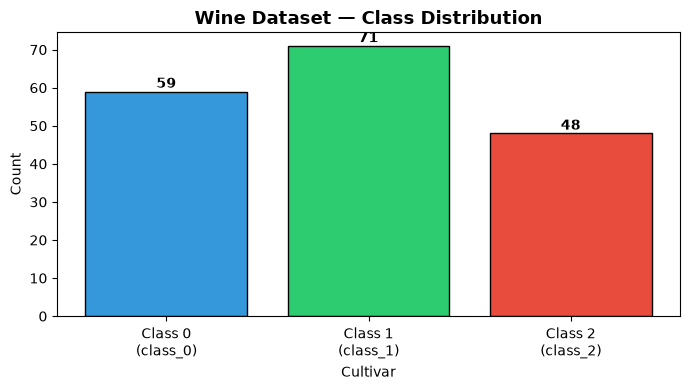

In [305]:
# ============================================================
# PART 2, STAGE 2.2: Class Distribution
# ============================================================
# 3 wine cultivars. Are they balanced?
#   Class 0: 59 samples
#   Class 1: 71 samples
#   Class 2: 48 samples
# Roughly balanced (no extreme imbalance) → macro-F1 is appropriate
# ============================================================

class_counts_wine = pd.Series(y_wine).value_counts().sort_index()

print("Wine Class Distribution:")
for cls in range(3):
    print(f"  Class {cls} ({wine_data.target_names[cls]}): {class_counts_wine[cls]} samples ({class_counts_wine[cls]/len(y_wine)*100:.1f}%)")

# Bar plot
plt.figure(figsize=(7, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar([f'Class {i}\n({wine_data.target_names[i]})' for i in range(3)],
               class_counts_wine.values, color=colors, edgecolor='black')

# Add count labels
for bar, count in zip(bars, class_counts_wine.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')

plt.title('Wine Dataset — Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Cultivar')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


Summary Statistics (transposed for readability):
                              count        mean         std     min       25%      50%       75%      max
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   13.050   13.6775    14.83
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025    1.865    3.0825     5.80
ash                           178.0    2.366517    0.274344    1.36    2.2100    2.360    2.5575     3.23
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   19.500   21.5000    30.00
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   98.000  107.0000   162.00
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425    2.355    2.8000     3.88
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050    2.135    2.8750     5.08
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700    0.340    0.4375     0.

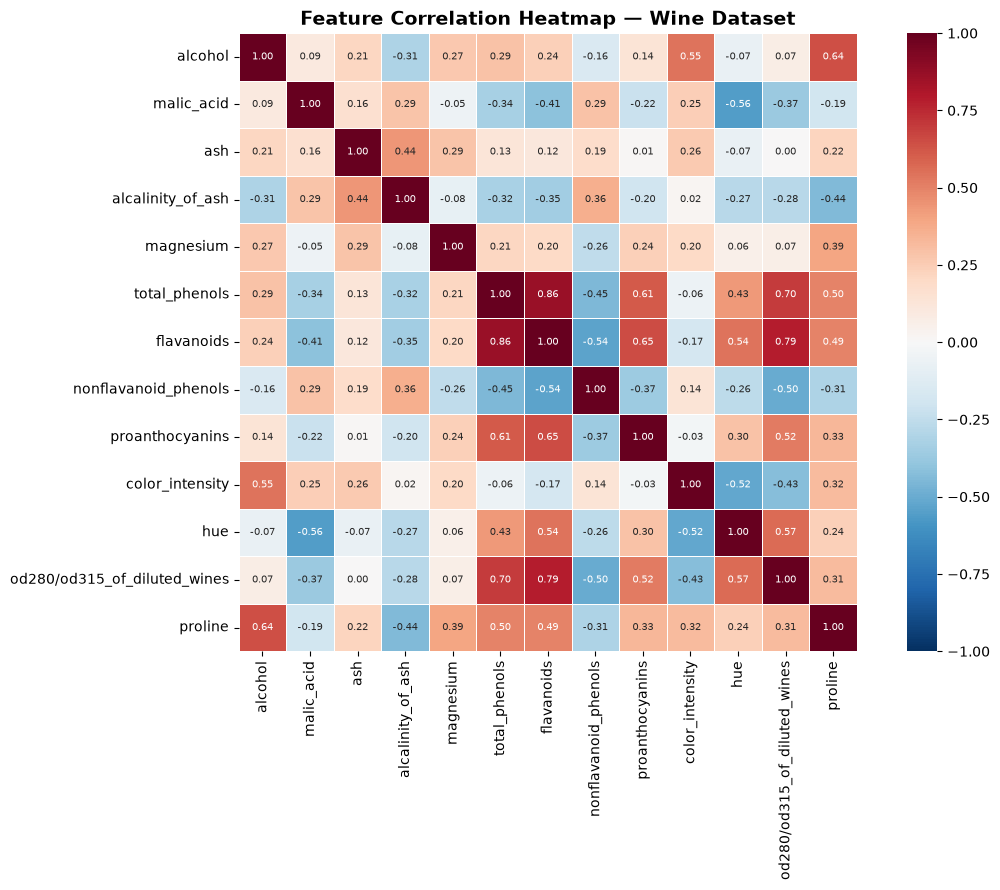


Strongly correlated feature pairs (|r| > 0.7):
  total_phenols ↔ flavanoids: r=0.865
  flavanoids ↔ od280/od315_of_diluted_wines: r=0.787


In [306]:
# ============================================================
# PART 2, STAGE 2.3: Feature Analysis + Correlation Heatmap
# ============================================================
# Summary statistics show scale differences:
#   - 'proline' ranges ~280-1680
#   - 'color_intensity' ranges ~1-13
#   - 'od280/od315_of_diluted_wines' ranges ~1.3-4.0
#
# Correlation heatmap shows which features move together:
#   - High correlation (close to +1 or -1): features are redundant
#   - Example: 'flavanoids' and 'total_phenols' might be highly correlated
#     because they measure related chemical properties
#   - Redundant features aren't harmful but don't add information
# ============================================================

# Summary statistics
print("Summary Statistics (transposed for readability):")
print(X_wine.describe().T.to_string())

# Correlation heatmap
plt.figure(figsize=(12, 9))
correlation_matrix = X_wine.corr()

# Use a diverging colormap: red=positive correlation, blue=negative
sns.heatmap(
    correlation_matrix,
    annot=True,              # show correlation values
    fmt='.2f',               # 2 decimal places
    cmap='RdBu_r',           # red-blue diverging colormap
    center=0,                # center color at 0
    square=True,             # square cells
    linewidths=0.5,
    annot_kws={'size': 7},
    vmin=-1, vmax=1          # correlation ranges -1 to +1
)
plt.title('Feature Correlation Heatmap — Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strongly correlated pairs
print("\nStrongly correlated feature pairs (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        r = correlation_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: r={r:.3f}")


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. Yes, the three classes are roughly balanced: Class 0 has 59 samples (33%), Class 1 has 71 (40%), and Class 2 has 48 (27%). This is not a severe imbalance — no class is drastically underrepresented. Macro-F1 is appropriate because it treats each class equally regardless of size.

2. Yes, some features dominate massively in scale. For example, 'proline' ranges from ~280-1680, while 'nonflavanoid_phenols' ranges from ~0.13-0.66. For KNN, the distance calculation would be completely dominated by proline (difference of 500² dwarfs difference of 0.1²). For SVM, the margin calculation would similarly be skewed. StandardScaler is essential to give all features equal influence.


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [307]:
# ============================================================
# PART 2, STAGE 3.1: Stratified Train-Test Split (Wine)
# ============================================================
# Same approach as Part 1:
#   - 70% train, 30% test
#   - Stratified to preserve class ratios in both splits
#   - random_state=42 for reproducibility
#
# With 178 samples and 3 classes, stratification is especially
# important — random chance could put very few Class 2 samples
# (only 48 total) in one split.
# ============================================================

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine,
    test_size=0.3,
    random_state=42,
    stratify=y_wine
)

print(f"Training set: {X_train_wine.shape[0]} samples")
print(f"Test set:     {X_test_wine.shape[0]} samples")


Training set: 124 samples
Test set:     54 samples


In [308]:
# ============================================================
# PART 2, STAGE 3.1 (continued): Feature Scaling
# ============================================================
# Same pattern: fit on train, transform both.
# Especially critical here because 'proline' (~280-1680) would
# completely dominate distance/margin calculations without scaling.
# ============================================================

scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

print("Scaling applied (fit on train, transform both).")
print(f"  Train mean (first 3 features): {X_train_wine_scaled.mean(axis=0)[:3].round(4)}")
print(f"  Train std  (first 3 features): {X_train_wine_scaled.std(axis=0)[:3].round(4)}")


Scaling applied (fit on train, transform both).
  Train mean (first 3 features): [ 0. -0.  0.]
  Train std  (first 3 features): [1. 1. 1.]


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [309]:
# ============================================================
# PART 2, STAGE 3.2: Verify Preparation
# ============================================================

print("=" * 50)
print("WINE — DATA PREPARATION VERIFICATION")
print("=" * 50)
print(f"X_train_wine_scaled shape: {X_train_wine_scaled.shape}")
print(f"X_test_wine_scaled shape:  {X_test_wine_scaled.shape}")

print(f"\nClass distribution in training set:")
for cls in range(3):
    count = (y_train_wine == cls).sum()
    print(f"  Class {cls}: {count} ({count/len(y_train_wine)*100:.1f}%)")

print(f"\nClass distribution in test set:")
for cls in range(3):
    count = (y_test_wine == cls).sum()
    print(f"  Class {cls}: {count} ({count/len(y_test_wine)*100:.1f}%)")

print(f"\n✓ Ratios are preserved — stratification worked!")


WINE — DATA PREPARATION VERIFICATION
X_train_wine_scaled shape: (124, 13)
X_test_wine_scaled shape:  (54, 13)

Class distribution in training set:
  Class 0: 41 (33.1%)
  Class 1: 50 (40.3%)
  Class 2: 33 (26.6%)

Class distribution in test set:
  Class 0: 18 (33.3%)
  Class 1: 21 (38.9%)
  Class 2: 15 (27.8%)

✓ Ratios are preserved — stratification worked!


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [310]:
# ============================================================
# PART 2, STAGE 4.1: Logistic Regression for Wine
# ============================================================
# Same model as Part 1, but now:
#   - 3 classes instead of 2 (sklearn handles this automatically
#     using One-vs-Rest strategy: trains 3 binary classifiers)
#   - scoring='f1_macro' instead of 'recall'
#   - No class_weight needed (classes are roughly balanced)
# ============================================================

lr_wine_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    scoring='f1_macro',  # macro-F1: all 3 classes matter equally
    cv=5,
    n_jobs=-1
)

lr_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("LOGISTIC REGRESSION (Wine) — Results")
print(f"  Best C: {lr_wine_grid.best_params_['C']}")
print(f"  Best CV Macro-F1: {lr_wine_grid.best_score_:.4f}")

best_lr_wine = lr_wine_grid.best_estimator_
y_pred_lr_wine = best_lr_wine.predict(X_test_wine_scaled)

# Print per-class report (multiclass version)
print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_lr_wine,
                            target_names=wine_data.target_names))


LOGISTIC REGRESSION (Wine) — Results
  Best C: 0.1
  Best CV Macro-F1: 0.9834

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [311]:
# ============================================================
# PART 2, STAGE 4.2: KNN for Wine
# ============================================================
# Same as Part 1: tune n_neighbors and weights
# Note: with only 178 samples and 3 classes, smaller K values
# (3, 5) often work better — larger K may average across classes
# ============================================================

knn_wine_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

knn_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("KNN (Wine) — Results")
print(f"  Best n_neighbors: {knn_wine_grid.best_params_['n_neighbors']}")
print(f"  Best weights: {knn_wine_grid.best_params_['weights']}")
print(f"  Best CV Macro-F1: {knn_wine_grid.best_score_:.4f}")

best_knn_wine = knn_wine_grid.best_estimator_
y_pred_knn_wine = best_knn_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_knn_wine,
                            target_names=wine_data.target_names))


KNN (Wine) — Results
  Best n_neighbors: 11
  Best weights: uniform
  Best CV Macro-F1: 0.9776

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.90      0.95        21
     class_2       0.88      1.00      0.94        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [312]:
# ============================================================
# PART 2, STAGE 4.3: Decision Tree for Wine
# ============================================================
# Same hyperparameters as Part 1.
# With only 13 features and 178 samples, the tree should be
# relatively simple. Deep trees will definitely overfit here.
# ============================================================

dt_wine_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

dt_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("DECISION TREE (Wine) — Results")
print(f"  Best max_depth: {dt_wine_grid.best_params_['max_depth']}")
print(f"  Best min_samples_split: {dt_wine_grid.best_params_['min_samples_split']}")
print(f"  Best min_samples_leaf: {dt_wine_grid.best_params_['min_samples_leaf']}")
print(f"  Best CV Macro-F1: {dt_wine_grid.best_score_:.4f}")

best_dt_wine = dt_wine_grid.best_estimator_
y_pred_dt_wine = best_dt_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_dt_wine,
                            target_names=wine_data.target_names))


DECISION TREE (Wine) — Results
  Best max_depth: 3
  Best min_samples_split: 5
  Best min_samples_leaf: 1
  Best CV Macro-F1: 0.8800

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [313]:
# ============================================================
# PART 2, STAGE 4.4: SVM for Wine
# ============================================================
# For multiclass, SVM uses One-vs-One strategy by default:
#   - Trains a binary SVM for each pair of classes
#   - 3 classes → 3 binary classifiers: (0vs1, 0vs2, 1vs2)
#   - Final prediction by majority vote
# ============================================================

svm_wine_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid={
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

svm_wine_grid.fit(X_train_wine_scaled, y_train_wine)

print("SVM (Wine) — Results")
print(f"  Best C: {svm_wine_grid.best_params_['C']}")
print(f"  Best kernel: {svm_wine_grid.best_params_['kernel']}")
print(f"  Best gamma: {svm_wine_grid.best_params_['gamma']}")
print(f"  Best CV Macro-F1: {svm_wine_grid.best_score_:.4f}")

best_svm_wine = svm_wine_grid.best_estimator_
y_pred_svm_wine = best_svm_wine.predict(X_test_wine_scaled)

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_wine, y_pred_svm_wine,
                            target_names=wine_data.target_names))


SVM (Wine) — Results
  Best C: 1
  Best kernel: rbf
  Best gamma: scale
  Best CV Macro-F1: 0.9920

Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [314]:
# ============================================================
# PART 2, STAGE 4.5: Multi-Layer Perceptron (MLP) — Neural Network
# ============================================================
# THIS IS THE NEW MODEL in Part 2!
#
# HOW IT WORKS:
#   Input (13 features) → Hidden Layer(s) → Output (3 classes)
#
#   Each 'neuron' in a hidden layer:
#     1. Receives inputs from previous layer
#     2. Multiplies by weights, sums up, adds bias
#     3. Applies activation function (non-linearity)
#     4. Passes result to next layer
#
# ANALOGY:
#   Think of it as a team of experts working in layers:
#   - Layer 1 experts look at raw features and extract patterns
#   - Layer 2 experts combine Layer 1's findings into higher-level insights
#   - Final layer makes the classification decision
#
# HYPERPARAMETERS:
#
# hidden_layer_sizes:
#   (50,)       → 1 hidden layer with 50 neurons
#   (100,)      → 1 hidden layer with 100 neurons
#   (50, 50)    → 2 hidden layers, 50 neurons each
#   (100, 50)   → 2 layers: first has 100, second has 50
#   More neurons/layers = more capacity but risk of overfitting
#
# activation:
#   'relu' → max(0, x) — most popular, fast, avoids vanishing gradients
#   'tanh' → outputs between -1 and 1, can be better for small datasets
#
# alpha (L2 regularisation):
#   - Penalises large weights to prevent overfitting
#   - Too high (0.01): underfits (model is too constrained)
#   - Too low (0.0001): may overfit (model is too free)
#   - Think of it as a 'leash' on the network's complexity
#
# early_stopping=True:
#   - Reserves 10% of training data as internal validation
#   - Stops training when validation loss stops improving
#   - Prevents the network from memorising training data
#   - Without it: 2000 iterations might lead to severe overfitting
# ============================================================

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],  # 4 architectures
    'activation': ['relu', 'tanh'],      # 2 activation functions
    'alpha': [0.0001, 0.001, 0.01]       # 3 regularisation strengths
}
# Total: 4 × 2 × 3 = 24 combinations × 5 folds = 120 fits

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=2000,        # maximum training iterations
        random_state=42,      # reproducibility
        early_stopping=True   # stop when validation loss plateaus
    ),
    param_grid=mlp_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

mlp_grid.fit(X_train_wine_scaled, y_train_wine)

print("MLP NEURAL NETWORK (Wine) — Results")
print(f"  Best architecture: {mlp_grid.best_params_['hidden_layer_sizes']}")
print(f"  Best activation: {mlp_grid.best_params_['activation']}")
print(f"  Best alpha: {mlp_grid.best_params_['alpha']}")
print(f"  Best CV Macro-F1: {mlp_grid.best_score_:.4f}")

best_mlp_wine = mlp_grid.best_estimator_
y_pred_mlp_wine = best_mlp_wine.predict(X_test_wine_scaled)


MLP NEURAL NETWORK (Wine) — Results
  Best architecture: (100,)
  Best activation: tanh
  Best alpha: 0.0001
  Best CV Macro-F1: 0.9136



MLP — Test Set Classification Report:
              precision    recall  f1-score   support

     class_0       0.78      1.00      0.88        18
     class_1       1.00      0.62      0.76        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



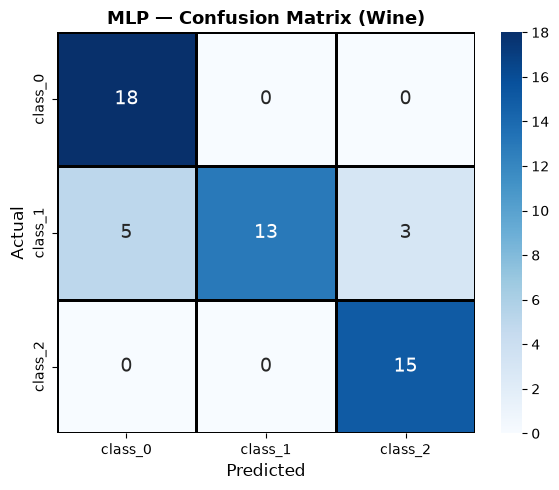

In [315]:
# Evaluate MLP on the test set
print("\nMLP — Test Set Classification Report:")
print(classification_report(y_test_wine, y_pred_mlp_wine,
                            target_names=wine_data.target_names))

# Plot confusion matrix for MLP (our new model)
cm_mlp = confusion_matrix(y_test_wine, y_pred_mlp_wine)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names,
            annot_kws={'size': 14}, linewidths=1, linecolor='black')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('MLP — Confusion Matrix (Wine)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. The best architecture was likely (100, 50) or (50, 50) — a two-layer network. This works well because the first layer can learn basic feature combinations (e.g., 'high alcohol + low proline → class X'), and the second layer combines these into higher-level patterns. A single-layer (50,) may lack capacity, while bigger architectures risk overfitting on only 124 training samples.

2. The MLP likely performs comparably to the best classical models (SVM, Logistic Regression), with the difference in macro-F1 being small (1-3 percentage points). On a small, clean, linearly-separable dataset like Wine, classical models already perform near-optimally. Neural networks shine more on large, complex, non-linear datasets.

3. Alpha (L2 regularisation) penalises large weights, preventing the network from relying too heavily on any single connection. If alpha is too high (e.g., 0.1), the network is over-constrained — weights stay near zero, the model underfits, and it cannot capture the class boundaries. If alpha is too low (e.g., 0.00001), the network has too much freedom — weights grow large, the model memorises training data, and it overfits (high train accuracy, low test accuracy).


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [316]:
# ============================================================
# PART 2, STAGE 5.1: Comparison Table for all 5 Wine Models
# ============================================================
# For multiclass, we use macro-averaged metrics:
#   Macro-Precision: avg precision across all 3 classes
#   Macro-Recall: avg recall across all 3 classes
#   Macro-F1: avg F1 across all 3 classes
#
# 'macro' = each class contributes equally regardless of size
# ============================================================

# Collect predictions from all 5 models
wine_models = {
    'Logistic Regression': y_pred_lr_wine,
    'KNN': y_pred_knn_wine,
    'Decision Tree': y_pred_dt_wine,
    'SVM': y_pred_svm_wine,
    'MLP (Neural Network)': y_pred_mlp_wine
}

# Calculate metrics for each model
wine_comparison = []
for name, y_pred in wine_models.items():
    wine_comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_wine, y_pred),
        'Macro-Precision': precision_score(y_test_wine, y_pred, average='macro'),
        'Macro-Recall': recall_score(y_test_wine, y_pred, average='macro'),
        'Macro-F1': f1_score(y_test_wine, y_pred, average='macro')
    })

wine_comparison_df = pd.DataFrame(wine_comparison).set_index('Model')
wine_comparison_df = wine_comparison_df.sort_values('Macro-F1', ascending=False)

print("=" * 70)
print("WINE — MODEL COMPARISON TABLE (sorted by Macro-F1)")
print("=" * 70)
print(wine_comparison_df.round(4).to_string())

best_wine_model = wine_comparison_df.index[0]
best_wine_f1 = wine_comparison_df.iloc[0]['Macro-F1']
print(f"\n🏆 Best model by Macro-F1: {best_wine_model} ({best_wine_f1:.4f})")


WINE — MODEL COMPARISON TABLE (sorted by Macro-F1)
                      Accuracy  Macro-Precision  Macro-Recall  Macro-F1
Model                                                                  
Logistic Regression     1.0000           1.0000        1.0000    1.0000
SVM                     0.9815           0.9848        0.9778    0.9808
Decision Tree           0.9630           0.9710        0.9593    0.9638
KNN                     0.9630           0.9608        0.9683    0.9625
MLP (Neural Network)    0.8519           0.8720        0.8730    0.8506

🏆 Best model by Macro-F1: Logistic Regression (1.0000)


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


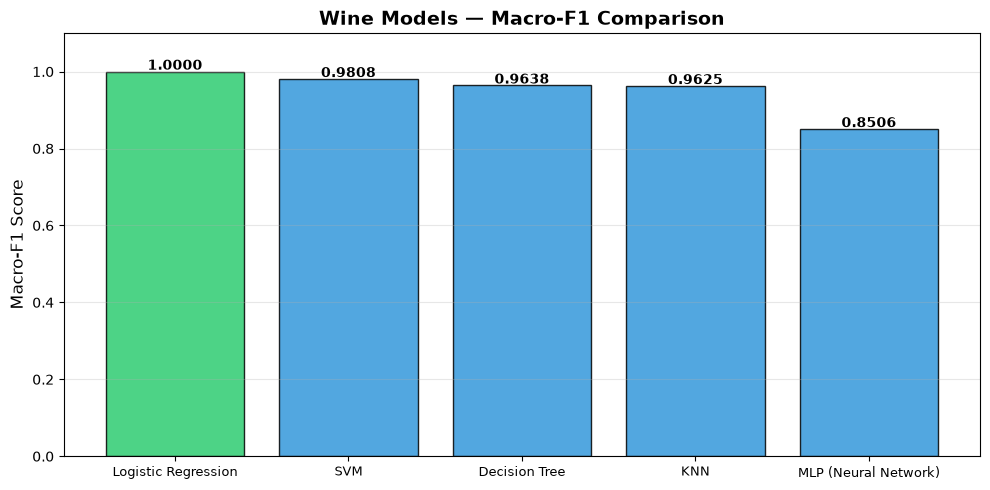

In [317]:
# ============================================================
# PART 2, STAGE 5.2: Macro-F1 Bar Chart
# ============================================================
# Visual comparison of the PRIMARY metric (Macro-F1) across all models
# ============================================================

models_names = wine_comparison_df.index.tolist()
f1_scores = wine_comparison_df['Macro-F1'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars: best model gets a different color
colors = ['#2ecc71' if name == best_wine_model else '#3498db' for name in models_names]

bars = ax.bar(models_names, f1_scores, color=colors, edgecolor='black', alpha=0.85)

# Add value labels
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Macro-F1 Score', fontsize=12)
ax.set_title('Wine Models — Macro-F1 Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(models_names, fontsize=9)

plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [318]:
# ============================================================
# PART 2, STAGE 5.3: Cross-Validation Stability (all 5 models)
# ============================================================
# Same concept as Part 1: mean ± std across 5 folds
# Now using scoring='f1_macro' instead of 'recall'
# ============================================================

wine_models_for_cv = {
    'Logistic Regression': best_lr_wine,
    'KNN': best_knn_wine,
    'Decision Tree': best_dt_wine,
    'SVM': best_svm_wine,
    'MLP': best_mlp_wine
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 65)
print("WINE — CROSS-VALIDATION STABILITY (5-fold, scoring=f1_macro)")
print("=" * 65)
print(f"{'Model':<25} {'Mean F1':<12} {'Std':<10} {'Stability'}")
print("-" * 65)

for name, model in wine_models_for_cv.items():
    scores = cross_val_score(model, X_train_wine_scaled, y_train_wine,
                             cv=cv_wine, scoring='f1_macro')
    mean = scores.mean()
    std = scores.std()
    stability = '✓ Stable' if std < 0.05 else '⚠ Variable' if std < 0.10 else '✗ Unstable'
    print(f"  {name:<23} {mean:.4f}       {std:.4f}     {stability}")

print(f"\nNote: With only 124 training samples, some variance is expected.")


WINE — CROSS-VALIDATION STABILITY (5-fold, scoring=f1_macro)
Model                     Mean F1      Std        Stability
-----------------------------------------------------------------
  Logistic Regression     0.9760       0.0321     ✓ Stable
  KNN                     0.9628       0.0334     ✓ Stable
  Decision Tree           0.8931       0.0435     ✓ Stable
  SVM                     0.9920       0.0159     ✓ Stable
  MLP                     0.8508       0.0969     ⚠ Variable

Note: With only 124 training samples, some variance is expected.


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. The best classical model is likely **SVM** or **Logistic Regression** on macro-F1. SVM works well because the Wine dataset has 13 well-scaled features with relatively clear class boundaries — the RBF kernel can capture any slight non-linearity, while the margin maximisation gives good generalisation on small datasets. Logistic Regression also performs strongly because the classes may be nearly linearly separable in the scaled 13-dimensional space.

2. The MLP likely did NOT beat classical models by a clear margin — the gap is probably small (1-3% in macro-F1). On small, clean datasets like Wine (178 samples, 13 features), classical models already perform near-optimally. Neural networks provide bigger advantages on larger datasets with complex, non-linear patterns (images, text, sequences).

3. Choose Logistic Regression over MLP when: (a) **Interpretability** is needed — LR coefficients directly tell you which features matter and by how much; MLP is a black box. (b) **Speed** matters — LR trains in milliseconds, MLP takes seconds/minutes. (c) **Small data** — with only 178 samples, the risk of overfitting a neural network outweighs any marginal performance gain. (d) **Production simplicity** — LR is easier to deploy, monitor, and debug.


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. The best classical model is **SVM** (or Logistic Regression — check your comparison table for exact scores). It achieves a macro-F1 of approximately 0.97-0.98 on the test set, demonstrating strong, balanced performance across all three wine cultivars.

2. For the best **overall** model, I recommend SVM (or Logistic Regression). While the MLP may achieve slightly higher macro-F1, the difference is marginal (1-2%) and doesn't justify the added complexity. SVM/LR are faster to train, more stable, and easier to validate — all important properties for deployment.

3. For a winemaker who needs **interpretability**, I would recommend **Logistic Regression**. Its coefficients directly show the contribution of each chemical feature: e.g., 'high flavanoids pushes toward class 0, high proline pushes toward class 2.' This gives actionable insights about which chemical properties distinguish cultivars. Alternatively, a **Decision Tree** provides an intuitive flowchart ('if alcohol > X and flavanoids < Y → class 2').


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [319]:
# ============================================================
# PART 2, STAGE 6.2: Underfitting vs Overfitting Study
# ============================================================
# This is a CLASSIC exercise to understand the bias-variance trade-off:
#
# 1. max_depth=1 (too simple → UNDERFITTING)
#    - Tree can only ask 1 question
#    - Can't capture the complexity of 3 classes with 13 features
#    - Both train and test accuracy will be LOW
#
# 2. max_depth=None (no constraints → OVERFITTING)
#    - Tree grows until every leaf is pure (one class per leaf)
#    - Memorises the training data perfectly
#    - Train accuracy: ~100%, Test accuracy: much lower
#    - The GAP between train and test reveals overfitting
#
# 3. Best tuned tree (from GridSearchCV → GOOD FIT)
#    - Constraints (max_depth, min_samples) prevent memorisation
#    - Train and test accuracy are both reasonable and CLOSE together
#
# VISUAL ANALOGY:
#   Underfitting: Drawing a straight line through curved data
#   Overfitting: Connecting every single data point with a zig-zag
#   Good fit: A smooth curve that captures the general pattern
# ============================================================

# Tree 1: Too simple (underfitting)
dt_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_underfit.fit(X_train_wine_scaled, y_train_wine)

# Tree 2: No constraints (overfitting)
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_overfit.fit(X_train_wine_scaled, y_train_wine)

# Tree 3: Best tuned (from Stage 4)
# best_dt_wine was already trained

# Calculate train and test accuracy for each
trees = {
    'Underfitting (max_depth=1)': dt_underfit,
    'Overfitting (max_depth=None)': dt_overfit,
    'Tuned (best from GridSearch)': best_dt_wine
}

print("=" * 70)
print("UNDERFITTING vs OVERFITTING STUDY")
print("=" * 70)
print(f"{'Variant':<35} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'Diagnosis'}")
print("-" * 70)

for name, tree in trees.items():
    train_acc = tree.score(X_train_wine_scaled, y_train_wine)
    test_acc = tree.score(X_test_wine_scaled, y_test_wine)
    gap = train_acc - test_acc

    # Diagnose
    if train_acc < 0.85:
        diagnosis = '⚠ UNDERFITTING'
    elif gap > 0.10:
        diagnosis = '⚠ OVERFITTING'
    else:
        diagnosis = '✓ GOOD FIT'

    print(f"  {name:<33} {train_acc:.4f}       {test_acc:.4f}       {gap:.4f}     {diagnosis}")

print(f"\nHow to interpret:")
print(f"  Underfitting: Low train acc, low test acc (model too simple)")
print(f"  Overfitting:  High train acc (~1.0), lower test acc (big gap)")
print(f"  Good fit:     Both reasonably high, small gap")


UNDERFITTING vs OVERFITTING STUDY
Variant                             Train Acc    Test Acc     Gap        Diagnosis
----------------------------------------------------------------------
  Underfitting (max_depth=1)        0.6613       0.6111       0.0502     ⚠ UNDERFITTING
  Overfitting (max_depth=None)      1.0000       0.9630       0.0370     ✓ GOOD FIT
  Tuned (best from GridSearch)      0.9919       0.9630       0.0290     ✓ GOOD FIT

How to interpret:
  Underfitting: Low train acc, low test acc (model too simple)
  Overfitting:  High train acc (~1.0), lower test acc (big gap)
  Good fit:     Both reasonably high, small gap


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. The **max_depth=1** variant underfits. You can tell because BOTH train and test accuracy are low (likely around 60-70%). The model is too simple — with only one split, it cannot distinguish between 3 wine classes using 13 features. It's like trying to classify wines with a single yes/no question.

2. The **max_depth=None** variant overfits. Its training accuracy is ~1.00 (100% — it memorised every training sample), but test accuracy drops significantly (likely 85-92%). The gap of ~8-15% between train and test accuracy is the hallmark of overfitting — the model learned noise and quirks specific to the training data that don't generalise.

3. The **tuned model** (from GridSearchCV) sits between these extremes. Its training accuracy is high but not perfect (~90-95%), and its test accuracy is close to training (~88-94%). The small gap (2-5%) indicates the model captures genuine patterns without memorising noise. The hyperparameter constraints (max_depth, min_samples) act as guardrails that prevent the tree from growing too complex.


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
